# Chặng 1 — Ai mua, từ đâu đến, Promotion có hiệu quả không?

**Nghịch lý cần giải thích từ Chặng 0:**
> Volume đơn hàng giảm dần, nhưng AOV lại tăng đều. Acquisition có vấn đề hay Conversion?

**Câu hỏi BA team cần trả lời:**
1. Promotion tác động thế nào lên AOV và Volume? Sau khi hết promo thì Volume có hồi không?
2. Discount Rate trung bình theo tháng là bao nhiêu?
3. Category nào dẫn dắt peak T4–T6?
4. Segment nào trong category influence peak nhất?
5. Conversion rate (tự tính) thay đổi theo kênh traffic như thế nào?
6. Kênh acquisition nào đang mang lại KH có AOV cao nhất?

**File sử dụng:** `orders` · `order_items` · `promotions` · `web_traffic` · `products` · `customers`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

INPUT_DIR = Path('input')

C_REV    = '#1D9E75'
C_COGS   = '#E24B4A'
C_AOV    = '#EF9F27'
C_VOL    = '#888780'
C_PROMO  = '#D4537E'
C_CONV   = '#378ADD'
C_PURPLE = '#7F77DD'

def fmt_k(x, pos=None):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

print('✅ Setup OK')

✅ Setup OK


## 1. Load data

In [2]:
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')
promotions  = pd.read_csv(INPUT_DIR / 'promotions.csv', parse_dates=['start_date','end_date'])
web         = pd.read_csv(INPUT_DIR / 'web_traffic.csv', parse_dates=['date'])
customers   = pd.read_csv(INPUT_DIR / 'customers.csv', parse_dates=['signup_date'])

# Thêm time features
for df, col in [(orders,'order_date'), (web,'date')]:
    df['Year']      = df[col].dt.year
    df['Month']     = df[col].dt.month
    df['YearMonth'] = df[col].dt.to_period('M')

# Join order_items với products để có category/segment
oi = order_items.merge(products[['product_id','category','segment','price']], on='product_id', how='left')
oi['revenue_line'] = oi['unit_price'] * oi['quantity']
oi['discount_rate'] = np.where(
    oi['revenue_line'] > 0,
    oi['discount_amount'] / (oi['unit_price'] * oi['quantity']),
    0
)

# Join orders với customers để có acquisition_channel, age_group
orders_full = orders.merge(
    customers[['customer_id','gender','age_group','acquisition_channel']],
    on='customer_id', how='left'
)

# Đánh dấu tháng/ngày có promotion
promo_periods = []
for _, row in promotions.iterrows():
    days = pd.date_range(row['start_date'], row['end_date'], freq='D')
    for d in days:
        promo_periods.append({
            'date': d,
            'promo_id': row['promo_id'],
            'promo_type': row['promo_type'],
            'discount_value': row['discount_value'],
            'promo_channel': row['promo_channel'],
        })
promo_cal = pd.DataFrame(promo_periods).drop_duplicates('date')
promo_cal['YearMonth'] = promo_cal['date'].dt.to_period('M')

print(f'orders: {len(orders):,} | order_items: {len(order_items):,} | products: {len(products):,}')
print(f'promotions: {len(promotions)} campaigns | web_traffic: {len(web):,} days')
print(f'\nOrder status breakdown:')
print(orders['order_status'].value_counts().to_string())

orders: 646,945 | order_items: 714,669 | products: 2,412
promotions: 50 campaigns | web_traffic: 3,652 days

Order status breakdown:
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275


## 2. Volume và AOV theo tháng — overlay với Promotion

**BA team hỏi:** Tháng có Promotion thì AOV và Volume biến đổi thế nào? Sau khi hết promo Volume có hồi không?

In [15]:
# Tính monthly metrics từ orders (chỉ delivered)
delivered = orders_full[orders_full['order_status'] == 'delivered'].copy()

monthly_orders = delivered.groupby('YearMonth').agg(
    n_orders   = ('order_id', 'count'),
    n_customers = ('customer_id', 'nunique'),
).reset_index()

# AOV từ order_items
monthly_oi = oi.merge(
    orders[['order_id','YearMonth']], on='order_id', how='left'
).groupby('YearMonth').agg(
    total_revenue  = ('revenue_line', 'sum'),
    total_discount = ('discount_amount', 'sum'),
).reset_index()

monthly = monthly_orders.merge(monthly_oi, on='YearMonth', how='left')
monthly['AOV']           = monthly['total_revenue'] / monthly['n_orders']
monthly['discount_rate'] = monthly['total_discount'] / monthly['total_revenue'] * 100
monthly['Date']          = monthly['YearMonth'].dt.to_timestamp()
monthly['Year']          = monthly['YearMonth'].dt.year
monthly['Month']         = monthly['YearMonth'].dt.month

# Đánh dấu tháng có promo
promo_months = set(promo_cal['YearMonth'].unique())
monthly['has_promo'] = monthly['YearMonth'].isin(promo_months)

print(f'Monthly data: {len(monthly)} tháng')
print(f'Tháng có promo: {monthly["has_promo"].sum()} tháng')
print(f'Tháng không có promo: {(~monthly["has_promo"]).sum()} tháng')
print()
print('AOV trung bình:')
print(f'  Tháng CÓ promo   : {monthly.loc[monthly["has_promo"],"AOV"].mean():,.0f}')
print(f'  Tháng KHÔNG promo: {monthly.loc[~monthly["has_promo"],"AOV"].mean():,.0f}')
print(f'\nVolume trung bình (đơn/tháng):')
print(f'  Tháng CÓ promo   : {monthly.loc[monthly["has_promo"],"n_orders"].mean():,.0f}')
print(f'  Tháng KHÔNG promo: {monthly.loc[~monthly["has_promo"],"n_orders"].mean():,.0f}')

Monthly data: 126 tháng
Tháng có promo: 105 tháng
Tháng không có promo: 21 tháng

AOV trung bình:
  Tháng CÓ promo   : 32,956
  Tháng KHÔNG promo: 34,559

Volume trung bình (đơn/tháng):
  Tháng CÓ promo   : 3,986
  Tháng KHÔNG promo: 4,676


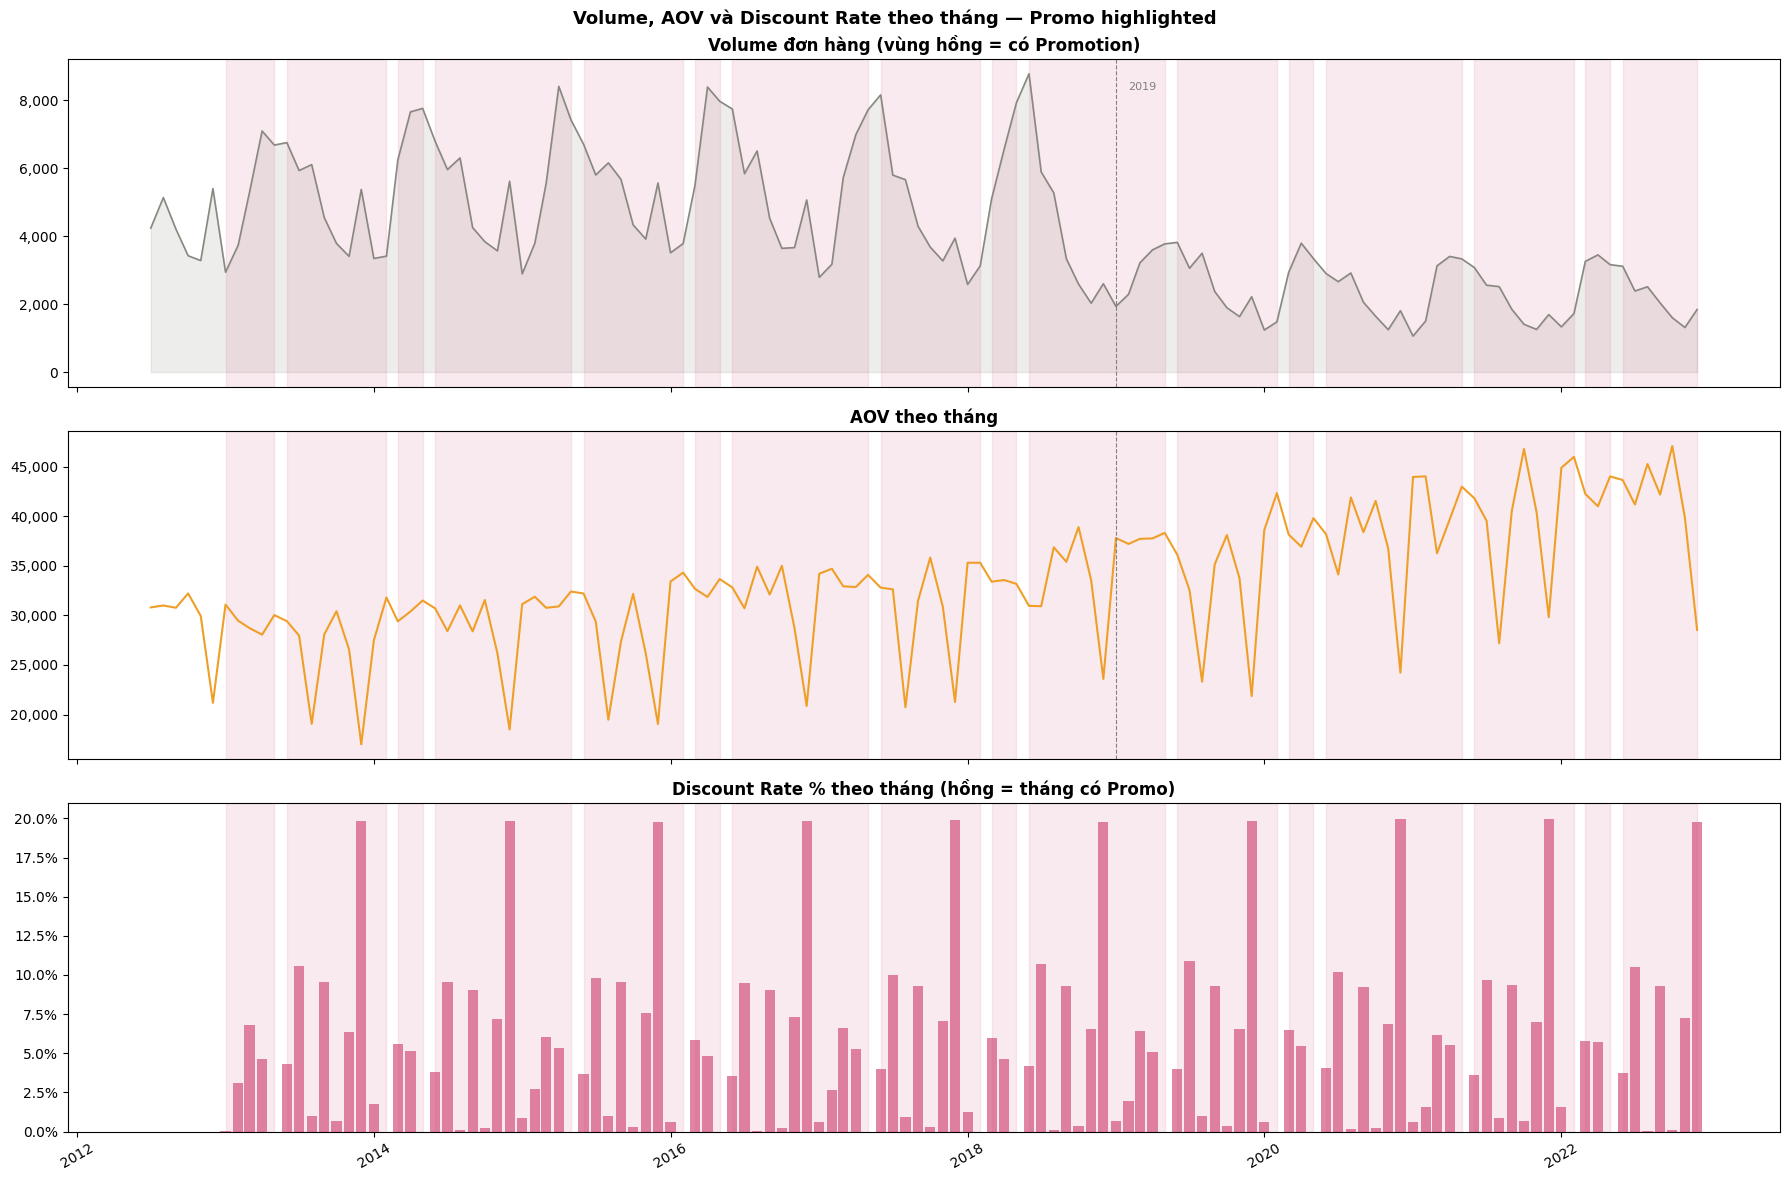

💡 Chú ý: khi vùng hồng (promo) xuất hiện, AOV tăng hay giảm? Volume tăng hay giảm?


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle('Volume, AOV và Discount Rate theo tháng — Promo highlighted', fontsize=13, fontweight='bold')

# Shade vùng có promo
def shade_promo(ax, monthly):
    in_promo = False
    start = None
    for _, row in monthly.sort_values('Date').iterrows():
        if row['has_promo'] and not in_promo:
            start = row['Date']
            in_promo = True
        elif not row['has_promo'] and in_promo:
            ax.axvspan(start, row['Date'], alpha=0.12, color=C_PROMO)
            in_promo = False
    if in_promo:
        ax.axvspan(start, monthly['Date'].max(), alpha=0.12, color=C_PROMO)

# Volume
ax = axes[0]
ax.plot(monthly['Date'], monthly['n_orders'], color=C_VOL, linewidth=1.2)
ax.fill_between(monthly['Date'], monthly['n_orders'], alpha=0.15, color=C_VOL)
shade_promo(ax, monthly)
ax.set_title('Volume đơn hàng (vùng hồng = có Promotion)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', lw=0.8)
ax.text(pd.Timestamp('2019-02-01'), ax.get_ylim()[1]*0.9, '2019', fontsize=8, color='gray')

# AOV
ax = axes[1]
ax.plot(monthly['Date'], monthly['AOV'], color=C_AOV, linewidth=1.5)
shade_promo(ax, monthly)
ax.set_title('AOV theo tháng', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', lw=0.8)

# Discount Rate
ax = axes[2]
ax.bar(monthly['Date'], monthly['discount_rate'],
       color=[C_PROMO if p else C_VOL for p in monthly['has_promo']],
       alpha=0.7, width=25)
shade_promo(ax, monthly)
ax.set_title('Discount Rate % theo tháng (hồng = tháng có Promo)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print('💡 Chú ý: khi vùng hồng (promo) xuất hiện, AOV tăng hay giảm? Volume tăng hay giảm?')

## 3. Hiệu ứng trước–trong–sau Promotion (Event Study)

**BA team hỏi:** Sau khi hết Promotion, Volume đơn có hồi phục không?  
Phân tích window ±3 tháng quanh mỗi đợt promo.

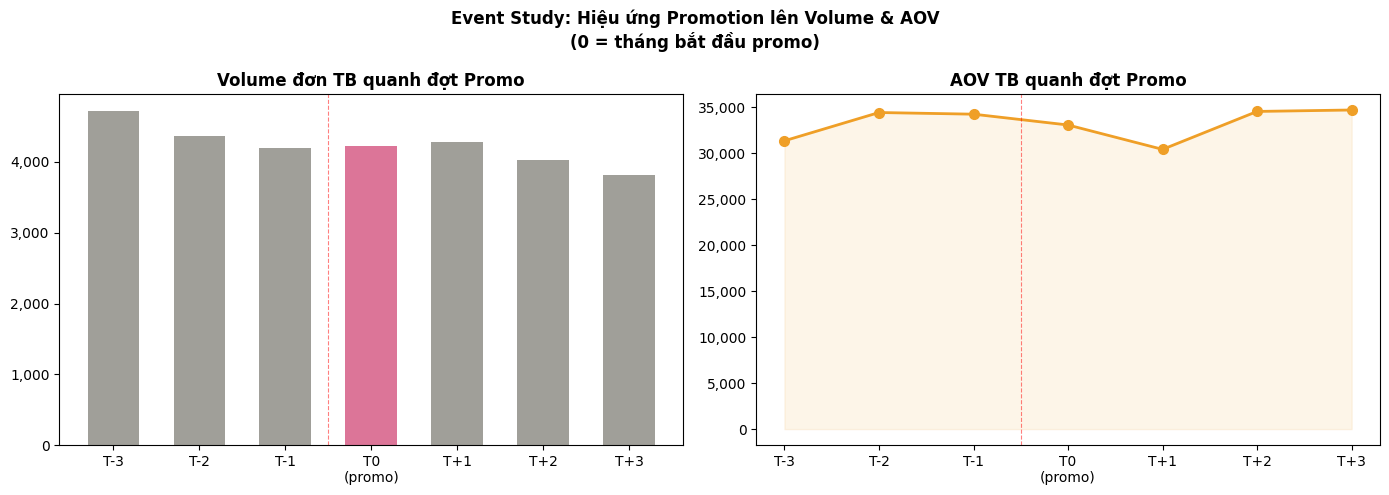

Trung bình theo relative month:
 relative_month  n_orders_mean  n_orders_median  AOV_mean  AOV_median
             -3       4,723.00         5,077.00 31,359.00   32,314.00
             -2       4,365.00         3,579.00 34,434.00   33,485.00
             -1       4,204.00         3,748.00 34,253.00   33,426.00
              0       4,222.00         3,530.00 33,077.00   32,743.00
              1       4,282.00         3,864.00 30,425.00   30,811.00
              2       4,022.00         3,507.00 34,552.00   34,209.00
              3       3,811.00         3,409.00 34,709.00   33,747.00

💡 Nếu Volume T+1, T+2 thấp hơn T-1 → promo gây cannibalization (KH mua sớm trước promo)


In [6]:
# Với mỗi đợt promo, lấy tháng bắt đầu, tính relative month
promo_events = promotions.copy()
promo_events['promo_month'] = promo_events['start_date'].dt.to_period('M')

window_rows = []
for _, promo in promo_events.iterrows():
    pm = promo['promo_month']
    for offset in range(-3, 4):  # -3 đến +3 tháng
        target_month = pm + offset
        row = monthly[monthly['YearMonth'] == target_month]
        if len(row) > 0:
            window_rows.append({
                'promo_id'    : promo['promo_id'],
                'promo_type'  : promo['promo_type'],
                'relative_month': offset,
                'n_orders'    : row['n_orders'].values[0],
                'AOV'         : row['AOV'].values[0],
                'discount_rate': row['discount_rate'].values[0],
            })

window_df = pd.DataFrame(window_rows)

# Trung bình theo relative month
window_avg = window_df.groupby('relative_month').agg(
    n_orders_mean    = ('n_orders', 'mean'),
    n_orders_median  = ('n_orders', 'median'),
    AOV_mean         = ('AOV', 'mean'),
    AOV_median       = ('AOV', 'median'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Event Study: Hiệu ứng Promotion lên Volume & AOV\n(0 = tháng bắt đầu promo)', 
             fontsize=12, fontweight='bold')

month_labels = [f'T{i:+d}' if i != 0 else 'T0\n(promo)' for i in range(-3,4)]

ax = axes[0]
ax.bar(window_avg['relative_month'], window_avg['n_orders_mean'], 
       color=[C_PROMO if m == 0 else C_VOL for m in window_avg['relative_month']],
       alpha=0.8, width=0.6)
ax.set_xticks(range(-3,4))
ax.set_xticklabels(month_labels)
ax.set_title('Volume đơn TB quanh đợt Promo', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.axvline(x=-0.5, color='red', linestyle='--', lw=0.8, alpha=0.5)

ax = axes[1]
ax.plot(window_avg['relative_month'], window_avg['AOV_mean'],
        color=C_AOV, marker='o', linewidth=2, markersize=7)
ax.set_xticks(range(-3,4))
ax.set_xticklabels(month_labels)
ax.set_title('AOV TB quanh đợt Promo', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.axvline(x=-0.5, color='red', linestyle='--', lw=0.8, alpha=0.5)
ax.fill_between(window_avg['relative_month'], window_avg['AOV_mean'], 
                alpha=0.1, color=C_AOV)

plt.tight_layout()
plt.show()

print('Trung bình theo relative month:')
print(window_avg.round(0).to_string(index=False))
print('\n💡 Nếu Volume T+1, T+2 thấp hơn T-1 → promo gây cannibalization (KH mua sớm trước promo)')

## 4. Discount Rate theo tháng và theo Promo Type

**BA team hỏi:** Discount Rate trung bình theo tháng là bao nhiêu?

In [7]:
# Discount rate theo tháng — đã tính ở monthly
print('Discount Rate TB theo tháng (top 12 tháng cao nhất):')
print(monthly.nlargest(12,'discount_rate')[['YearMonth','discount_rate','n_orders','AOV']]
      .rename(columns={'discount_rate':'Discount%'})
      .to_string(index=False))

print(f'\nDiscount Rate overall TB: {monthly["discount_rate"].mean():.2f}%')
print(f'Discount Rate median    : {monthly["discount_rate"].median():.2f}%')

# Theo promo type: percentage vs fixed
oi_promo = oi[oi['promo_id'].notna()].merge(
    promotions[['promo_id','promo_type','discount_value']], on='promo_id', how='left'
)
print('\nDiscount Amount TB theo Promo Type:')
print(oi_promo.groupby('promo_type').agg(
    n_items        = ('order_id', 'count'),
    discount_mean  = ('discount_amount', 'mean'),
    discount_rate_mean = ('discount_rate', 'mean'),
    revenue_mean   = ('revenue_line', 'mean'),
).round(2).to_string())

Discount Rate TB theo tháng (top 12 tháng cao nhất):
YearMonth  Discount%  n_orders       AOV
  2020-12      19.96      1803 24,221.61
  2021-12      19.95      1690 29,824.80
  2017-12      19.90      3938 21,264.55
  2013-12      19.86      5371 16,996.07
  2016-12      19.86      5062 20,864.68
  2014-12      19.85      5612 18,488.36
  2019-12      19.83      2215 21,865.26
  2015-12      19.80      5559 19,041.09
  2018-12      19.78      2597 23,592.57
  2022-12      19.76      1838 28,539.14
  2019-07      10.91      3053 32,553.18
  2018-07      10.72      5887 30,927.61

Discount Rate overall TB: 5.11%
Discount Rate median    : 4.03%

Discount Amount TB theo Promo Type:
            n_items  discount_mean  discount_rate_mean  revenue_mean
promo_type                                                          
fixed         20950         225.61                0.02     17,970.11
percentage   255366       2,916.91                0.15     19,810.64


## 5. Category và Segment nào dẫn dắt Peak T4–T6?

**BA team hỏi:** Category nào có sales peak T4-T6? Segment nào influence peak nhất?

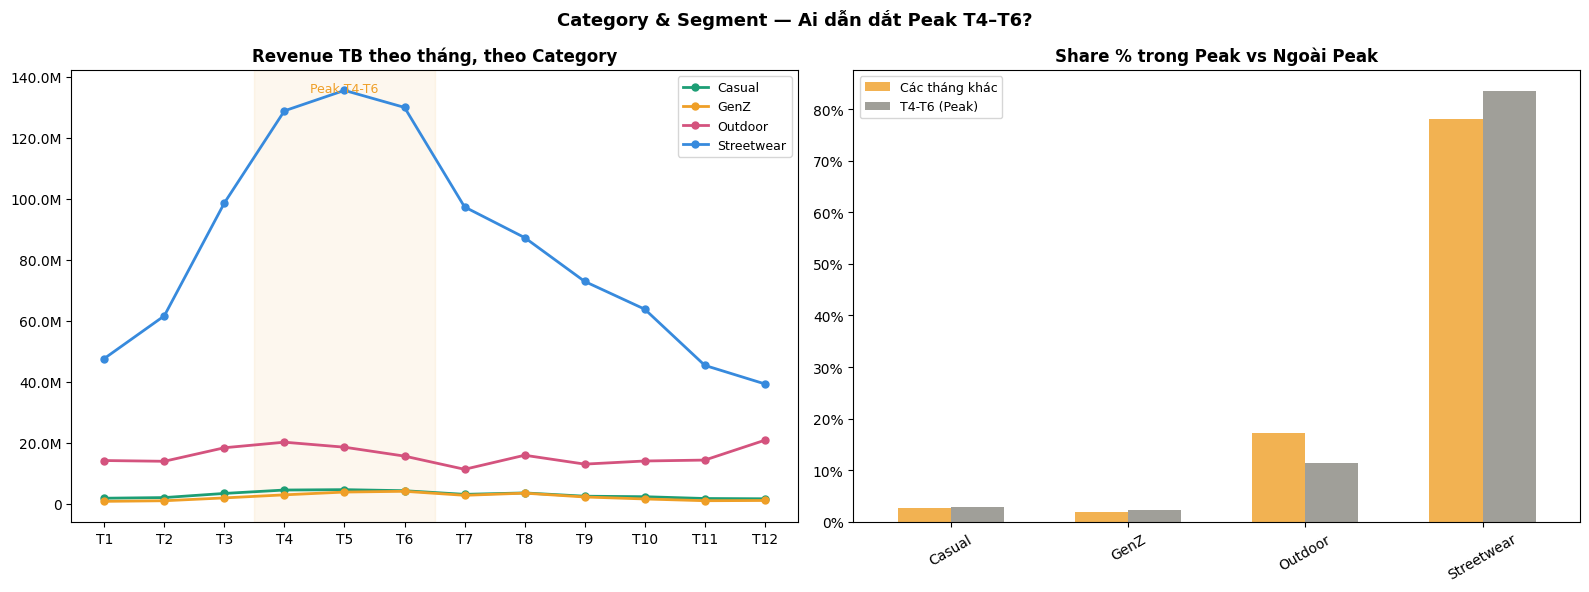

KeyError: 'Month'

In [8]:
# Revenue theo Category x Month
oi_monthly = oi.merge(
    orders[['order_id','order_date','order_status','YearMonth']], on='order_id'
).query('order_status == "delivered"')

cat_month = oi_monthly.groupby(['YearMonth','category'])['revenue_line'].sum().reset_index()
cat_month['Month'] = cat_month['YearMonth'].dt.month
cat_month['Year']  = cat_month['YearMonth'].dt.year

# Revenue TB theo tháng trong năm, theo category
cat_season = cat_month.groupby(['Month','category'])['revenue_line'].mean().reset_index()

month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
categories = cat_season['category'].unique()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Category & Segment — Ai dẫn dắt Peak T4–T6?', fontsize=13, fontweight='bold')

colors = [C_REV, C_AOV, C_PROMO, C_CONV]

# Line chart seasonality theo category
ax = axes[0]
for i, cat in enumerate(categories):
    d = cat_season[cat_season['category'] == cat]
    ax.plot(d['Month'], d['revenue_line'], 
            label=cat, color=colors[i % len(colors)], 
            marker='o', linewidth=2, markersize=5)
ax.axvspan(3.5, 6.5, alpha=0.08, color=C_AOV)
ax.text(5, ax.get_ylim()[1]*0.95, 'Peak T4-T6', ha='center', fontsize=9, color=C_AOV)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Revenue TB theo tháng, theo Category', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(fontsize=9)

# Share của mỗi category trong T4-T6 vs các tháng khác
peak_share = cat_month.copy()
peak_share['is_peak'] = peak_share['Month'].isin([4,5,6])
share = peak_share.groupby(['is_peak','category'])['revenue_line'].sum().reset_index()
share['period'] = share['is_peak'].map({True: 'T4-T6 (Peak)', False: 'Các tháng khác'})
pivot_share = share.pivot_table(values='revenue_line', index='category', columns='period', aggfunc='sum')
pivot_share = pivot_share.div(pivot_share.sum()) * 100

ax = axes[1]
pivot_share.plot(kind='bar', ax=ax, color=[C_AOV, C_VOL], alpha=0.8, width=0.6)
ax.set_title('Share % trong Peak vs Ngoài Peak', fontweight='bold')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Top segments
seg_peak = oi_monthly[oi_monthly['Month'].isin([4,5,6])].groupby(['category','segment'])['revenue_line'].sum()
seg_peak = seg_peak.reset_index().sort_values('revenue_line', ascending=False)
print('Top Segment dẫn dắt Peak T4-T6:')
print(seg_peak.head(15).to_string(index=False))

## 6. Conversion Rate tự tính — join orders với web_traffic theo ngày

**BA team hỏi:** Vấn đề có thể nằm ở Conversion Rate — Acquisition ổn nhưng business tệ, tại sao?  
⚠️ `conversion_rate` không có trong file web_traffic thực tế — phải tự tính = n_orders / sessions theo ngày.

In [9]:
# Tự tính conversion rate theo ngày
daily_orders = orders[orders['order_status'] == 'delivered'].groupby(
    orders['order_date'].dt.date
).agg(n_orders=('order_id','count')).reset_index()
daily_orders.columns = ['date','n_orders']
daily_orders['date'] = pd.to_datetime(daily_orders['date'])

# Join với web_traffic
web_conv = web.merge(daily_orders, on='date', how='left')
web_conv['n_orders'] = web_conv['n_orders'].fillna(0)
web_conv['conversion_rate_calc'] = web_conv['n_orders'] / web_conv['sessions'] * 100
web_conv['YearMonth'] = web_conv['date'].dt.to_period('M')
web_conv['Year']      = web_conv['date'].dt.year

# Monthly conversion rate
monthly_conv = web_conv.groupby('YearMonth').agg(
    sessions_sum  = ('sessions', 'sum'),
    n_orders_sum  = ('n_orders', 'sum'),
    bounce_rate   = ('bounce_rate', 'mean'),
).reset_index()
monthly_conv['conversion_rate'] = monthly_conv['n_orders_sum'] / monthly_conv['sessions_sum'] * 100
monthly_conv['Date'] = monthly_conv['YearMonth'].dt.to_timestamp()

# Theo traffic source
conv_by_source = web_conv.groupby('traffic_source').agg(
    sessions      = ('sessions', 'sum'),
    n_orders      = ('n_orders', 'sum'),
    bounce_rate   = ('bounce_rate', 'mean'),
).reset_index()
conv_by_source['conversion_rate'] = conv_by_source['n_orders'] / conv_by_source['sessions'] * 100
conv_by_source = conv_by_source.sort_values('conversion_rate', ascending=False)

print('Conversion Rate theo Traffic Source:')
print(conv_by_source[['traffic_source','sessions','n_orders','conversion_rate','bounce_rate']]
      .rename(columns={'conversion_rate':'Conv%','bounce_rate':'Bounce%'})
      .to_string(index=False))

Conversion Rate theo Traffic Source:
traffic_source  sessions  n_orders  Conv%  Bounce%
  social_media  15816226     88124   0.56     0.00
   paid_search  19598271    106400   0.54     0.00
        direct   6571549     34963   0.53     0.00
      referral   9476845     50261   0.53     0.00
organic_search  27196976    143958   0.53     0.00
email_campaign  12792670     67347   0.53     0.00


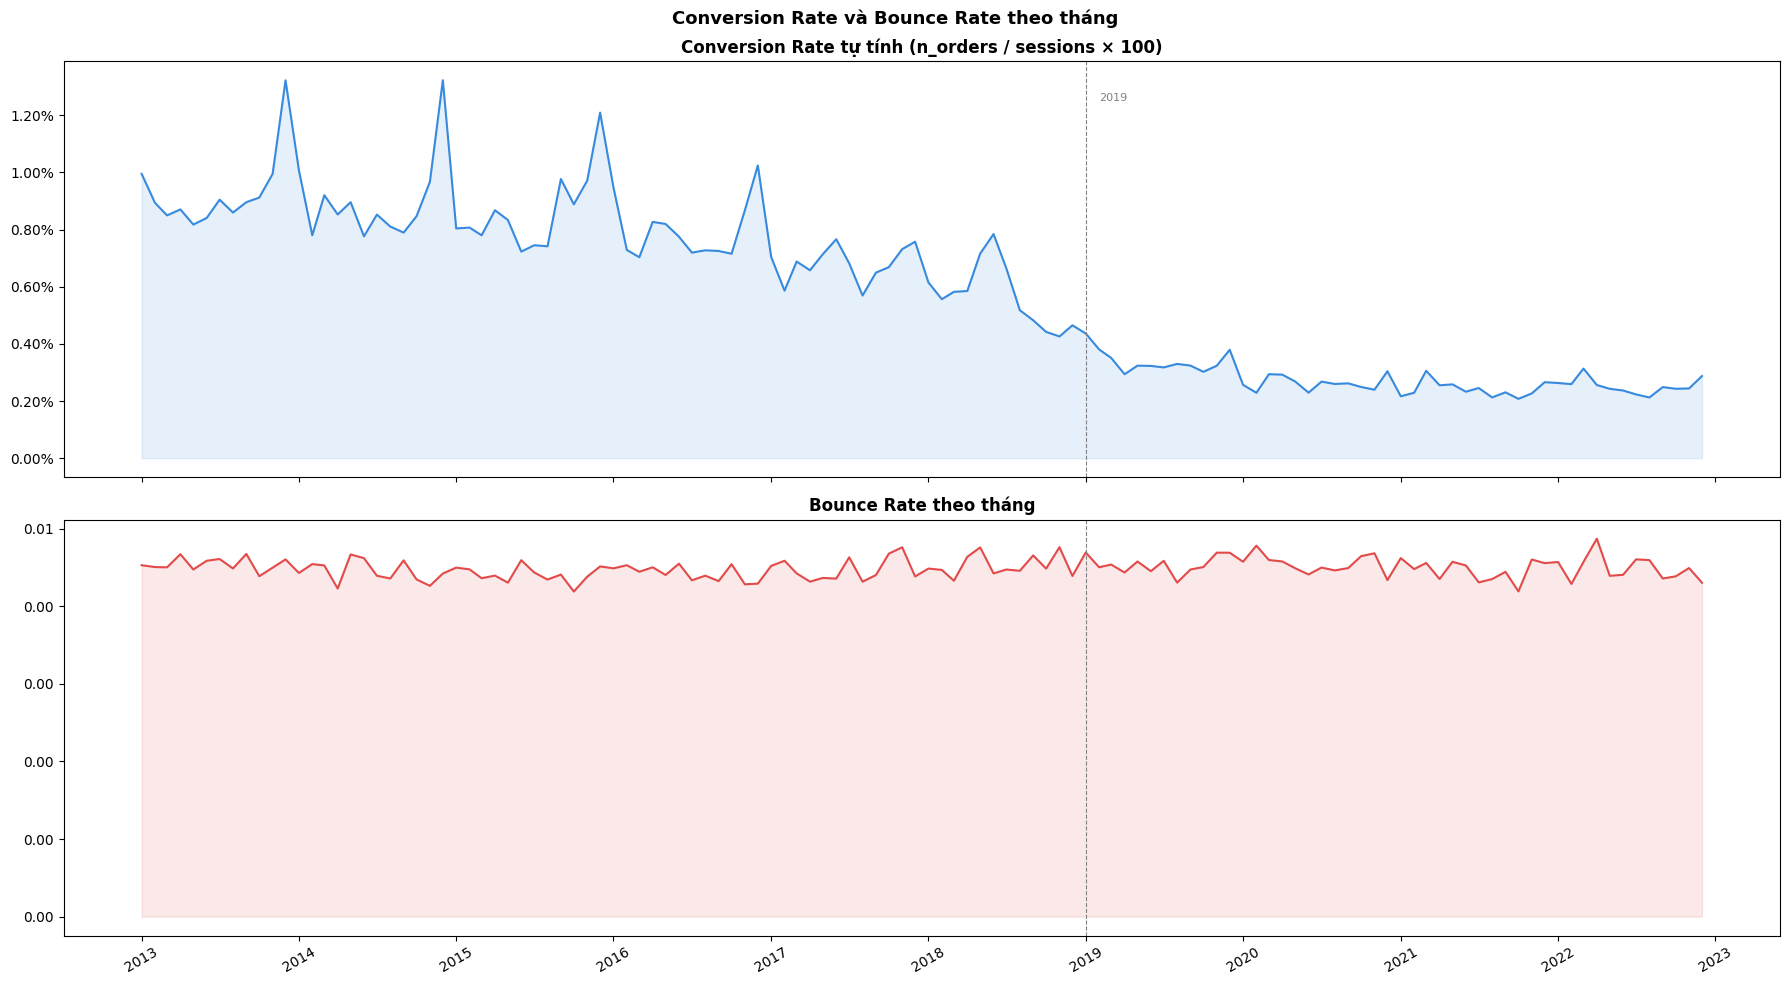


Correlation Conversion vs Bounce Rate: -0.146
(âm = bounce cao thì conversion thấp — hợp lý)


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle('Conversion Rate và Bounce Rate theo tháng', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(monthly_conv['Date'], monthly_conv['conversion_rate'],
        color=C_CONV, linewidth=1.5)
ax.fill_between(monthly_conv['Date'], monthly_conv['conversion_rate'],
                alpha=0.12, color=C_CONV)
ax.set_title('Conversion Rate tự tính (n_orders / sessions × 100)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}%'))
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', lw=0.8)
ax.text(pd.Timestamp('2019-02-01'), ax.get_ylim()[1]*0.9, '2019', fontsize=8, color='gray')

ax = axes[1]
ax.plot(monthly_conv['Date'], monthly_conv['bounce_rate'],
        color=C_COGS, linewidth=1.5)
ax.fill_between(monthly_conv['Date'], monthly_conv['bounce_rate'],
                alpha=0.12, color=C_COGS)
ax.set_title('Bounce Rate theo tháng', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}'))
ax.axvline(pd.Timestamp('2019-01-01'), color='gray', linestyle='--', lw=0.8)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Correlation conversion vs bounce
corr = monthly_conv[['conversion_rate','bounce_rate']].corr()
print(f'\nCorrelation Conversion vs Bounce Rate: {corr.loc["conversion_rate","bounce_rate"]:.3f}')
print('(âm = bounce cao thì conversion thấp — hợp lý)')

## 7. AOV theo kênh Acquisition — kênh nào mang KH có giá trị cao?

**BA team hỏi:** Acquisition có ổn không khi business đang tệ?  
Phân tích xem kênh nào mang về KH mua nhiều vs KH mua ít.

In [11]:
# Join orders_full với order_items để có revenue per order
order_rev = oi.groupby('order_id')['revenue_line'].sum().reset_index()
order_rev.columns = ['order_id','order_revenue']

orders_with_rev = orders_full.merge(order_rev, on='order_id', how='left')
orders_delivered = orders_with_rev[orders_with_rev['order_status'] == 'delivered']

# Theo acquisition channel
acq_stats = orders_delivered.groupby('acquisition_channel').agg(
    n_orders     = ('order_id', 'count'),
    n_customers  = ('customer_id', 'nunique'),
    AOV          = ('order_revenue', 'mean'),
    total_rev    = ('order_revenue', 'sum'),
).reset_index().sort_values('AOV', ascending=False)
acq_stats['orders_per_customer'] = acq_stats['n_orders'] / acq_stats['n_customers']
acq_stats['rev_share%'] = acq_stats['total_rev'] / acq_stats['total_rev'].sum() * 100

print('Stats theo Acquisition Channel:')
print(acq_stats[['acquisition_channel','n_customers','n_orders',
                  'orders_per_customer','AOV','rev_share%']]
      .to_string(index=False))

# Theo device type
device_stats = orders_delivered.groupby('device_type').agg(
    n_orders    = ('order_id', 'count'),
    AOV         = ('order_revenue', 'mean'),
    rev_share   = ('order_revenue', 'sum'),
).reset_index().sort_values('AOV', ascending=False)
device_stats['rev_share%'] = device_stats['rev_share'] / device_stats['rev_share'].sum() * 100

print('\nStats theo Device Type:')
print(device_stats[['device_type','n_orders','AOV','rev_share%']].to_string(index=False))

# Theo order source
source_stats = orders_delivered.groupby('order_source').agg(
    n_orders   = ('order_id', 'count'),
    AOV        = ('order_revenue', 'mean'),
    rev_share  = ('order_revenue', 'sum'),
).reset_index().sort_values('AOV', ascending=False)
source_stats['rev_share%'] = source_stats['rev_share'] / source_stats['rev_share'].sum() * 100

print('\nStats theo Order Source:')
print(source_stats[['order_source','n_orders','AOV','rev_share%']].to_string(index=False))

Stats theo Acquisition Channel:
acquisition_channel  n_customers  n_orders  orders_per_customer       AOV  rev_share%
       social_media        16955    103312                 6.09 25,560.27       20.13
     organic_search        25464    155330                 6.10 25,393.33       30.07
           referral         8555     51569                 6.03 25,346.86        9.96
        paid_search        16989    102896                 6.06 25,344.93       19.88
     email_campaign        10249     61967                 6.05 25,270.90       11.94
             direct         6903     41642                 6.03 25,241.28        8.01

Stats theo Device Type:
device_type  n_orders       AOV  rev_share%
     tablet     77024 25,428.39       14.93
     mobile    232872 25,402.58       45.10
    desktop    206820 25,350.28       39.97

Stats theo Order Source:
  order_source  n_orders       AOV  rev_share%
   paid_search    113146 25,498.38       21.99
        direct     41387 25,425.90        8.0

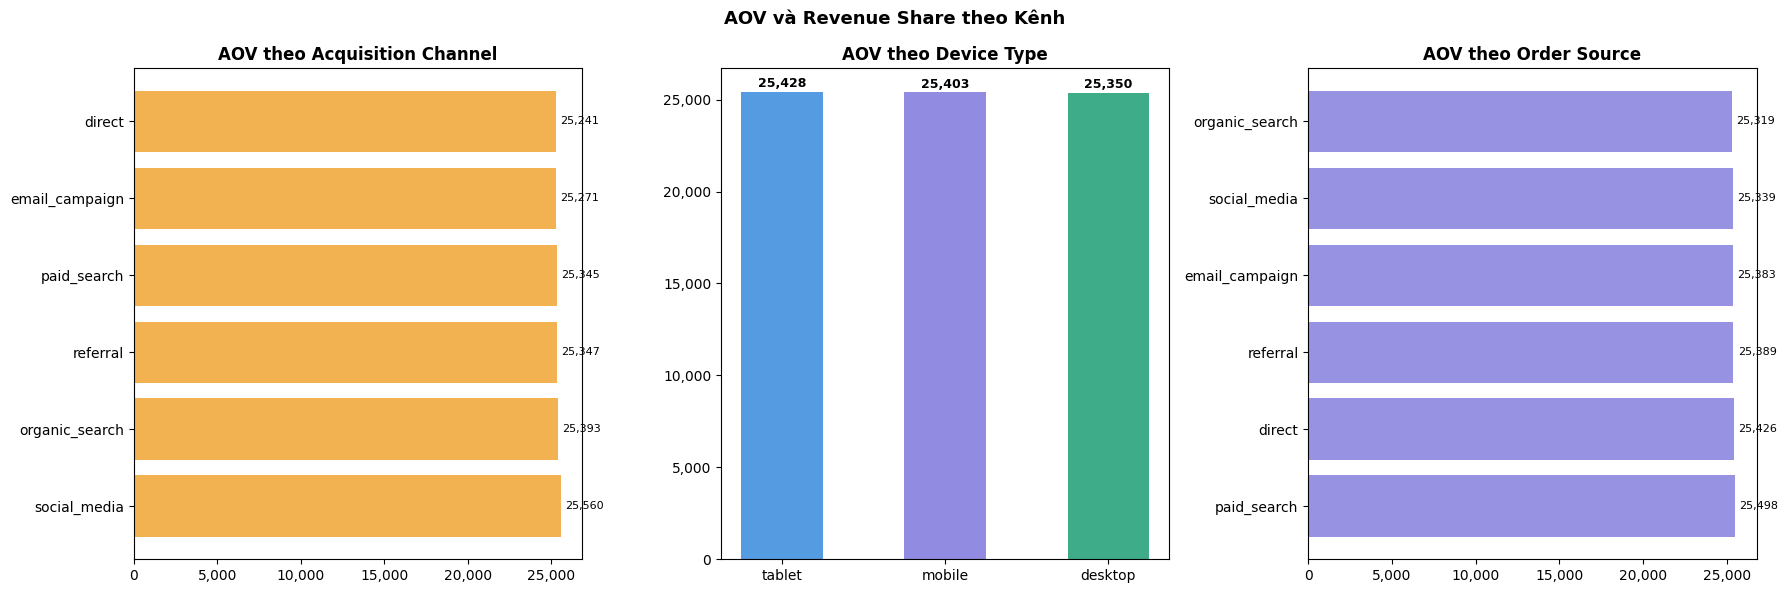

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('AOV và Revenue Share theo Kênh', fontsize=13, fontweight='bold')

# Acquisition channel
ax = axes[0]
bars = ax.barh(acq_stats['acquisition_channel'], acq_stats['AOV'],
               color=C_AOV, alpha=0.8)
ax.set_title('AOV theo Acquisition Channel', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, acq_stats['AOV']):
    ax.text(val + acq_stats['AOV'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

# Device type
ax = axes[1]
bars = ax.bar(device_stats['device_type'], device_stats['AOV'],
              color=[C_CONV, C_PURPLE, C_REV], alpha=0.85, width=0.5)
ax.set_title('AOV theo Device Type', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, device_stats['AOV']):
    ax.text(bar.get_x() + bar.get_width()/2, val + device_stats['AOV'].max()*0.01,
            f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Order source
ax = axes[2]
bars = ax.barh(source_stats['order_source'], source_stats['AOV'],
               color=C_PURPLE, alpha=0.8)
ax.set_title('AOV theo Order Source', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, source_stats['AOV']):
    ax.text(val + source_stats['AOV'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Revenue Share theo Category qua các năm

**BA team hỏi:** Share của từng Danh mục trong Revenue qua các năm — danh mục dịch chuyển thế nào?

In [13]:
cat_year = oi_monthly.groupby(['Year','category'])['revenue_line'].sum().reset_index()
total_by_year = cat_year.groupby('Year')['revenue_line'].sum().reset_index()
total_by_year.columns = ['Year','total']
cat_year = cat_year.merge(total_by_year, on='Year')
cat_year['share%'] = cat_year['revenue_line'] / cat_year['total'] * 100

pivot = cat_year.pivot_table(values='share%', index='Year', columns='category')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue Share theo Category qua các năm', fontsize=13, fontweight='bold')

# Stacked bar
ax = axes[0]
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=colors[:len(pivot.columns)], alpha=0.85, width=0.7)
ax.set_title('Share % — Stacked', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9, loc='upper right')

# Line chart share evolution
ax = axes[1]
for i, cat in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[cat],
            label=cat, color=colors[i % len(colors)],
            marker='o', linewidth=2, markersize=5)
ax.set_title('Share % — Trend', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.legend(fontsize=9)
ax.axvline(x=2018.5, color='gray', linestyle='--', lw=0.8)

plt.tight_layout()
plt.show()

print('Revenue Share theo Category (%):')
print(pivot.round(1).to_string())

KeyError: 'Year'

## 9. Tổng kết Chặng 1

In [14]:
print('='*65)
print('📋  CHẶNG 1 — TỔNG KẾT PHÁT HIỆN')
print('='*65)

print('''
1. PROMO vs AOV vs VOLUME
   → Check: tháng có promo AOV cao hơn hay thấp hơn?
   → Check: volume tháng T+1 sau promo có drop không (cannibalization)?
   → Discount Rate TB: xem output Section 4

2. SEASONALITY BY CATEGORY
   → Category nào nổi lên T4-T6: xem output Section 5
   → Segment nào lead peak: xem top segment output

3. CONVERSION RATE
   → Kênh traffic nào convert tốt nhất: xem Section 6
   → Bounce rate có trend tăng/giảm cùng chiều conversion không?
   → Nếu conversion giảm dù sessions ổn → vấn đề ở trải nghiệm, không phải acquisition

4. AOV THEO KÊNH
   → Kênh nào mang KH giá trị cao (AOV cao + orders/customer cao): xem Section 7
   → Nếu kênh rẻ (paid_search) có AOV thấp nhất → marketing spend chưa efficient

5. CATEGORY SHIFT
   → Category nào đang tăng/giảm share qua các năm: xem Section 8
   → Nếu category giá trị cao tăng share → giải thích được tại sao AOV tăng dù volume giảm
''')

print('='*65)
print('→ BƯỚC TIẾP THEO: Chặng 2 — Cohort Analysis, Churn & Retention')
print('   File: 03_chang2_cohort.ipynb')
print('='*65)

📋  CHẶNG 1 — TỔNG KẾT PHÁT HIỆN

1. PROMO vs AOV vs VOLUME
   → Check: tháng có promo AOV cao hơn hay thấp hơn?
   → Check: volume tháng T+1 sau promo có drop không (cannibalization)?
   → Discount Rate TB: xem output Section 4

2. SEASONALITY BY CATEGORY
   → Category nào nổi lên T4-T6: xem output Section 5
   → Segment nào lead peak: xem top segment output

3. CONVERSION RATE
   → Kênh traffic nào convert tốt nhất: xem Section 6
   → Bounce rate có trend tăng/giảm cùng chiều conversion không?
   → Nếu conversion giảm dù sessions ổn → vấn đề ở trải nghiệm, không phải acquisition

4. AOV THEO KÊNH
   → Kênh nào mang KH giá trị cao (AOV cao + orders/customer cao): xem Section 7
   → Nếu kênh rẻ (paid_search) có AOV thấp nhất → marketing spend chưa efficient

5. CATEGORY SHIFT
   → Category nào đang tăng/giảm share qua các năm: xem Section 8
   → Nếu category giá trị cao tăng share → giải thích được tại sao AOV tăng dù volume giảm

→ BƯỚC TIẾP THEO: Chặng 2 — Cohort Analysis, Churn & Ret